# 11 - Test Pipeline: YOLO → Crop → MobileNet
Kiểm tra toàn bộ inference pipeline trước khi deploy Flask server

In [1]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import time
from ultralytics import YOLO

In [9]:
# ── Config ────────────────────────────────────────────────────────────
YOLO_MODEL_PATH     = "../models/yolov8n_rice_leaf.pt"
MOBILENET_H5_PATH   = "../models/rice_disease_classifier.h5"
# MOBILENET_TFLITE  = "../models/rice_disease_quant.tflite"  # Dùng nếu muốn test tflite

TEST_DIR            = "../data/split/test"   # Dùng ảnh test set
CONF_THRESHOLD      = 0.3
PADDING             = 10

CLASS_NAMES = [
    "bacterial_blight",
    "barrow_brown_leaf_spot",
    "brown_spot",
    "healthy",
    "leaf_blast",
    "leaf_scald",
    "leaf_smut",
    # "neck_blast",
    "rice_hispa",
    "sheath_blight",
    "tungro"
]

print(f"TF version  : {tf.__version__}")
print(f"GPU         : {tf.config.list_physical_devices('GPU')}")

TF version  : 2.18.0
GPU         : []


In [10]:
# ── 1. Load models ────────────────────────────────────────────────────
yolo      = YOLO(YOLO_MODEL_PATH)
mobilenet = tf.keras.models.load_model(MOBILENET_H5_PATH)

print(f" YOLO     loaded: {YOLO_MODEL_PATH}")
print(f" MobileNet loaded: {MOBILENET_H5_PATH}")
print(f"   MobileNet input : {mobilenet.input_shape}")

 YOLO     loaded: ../models/yolov8n_rice_leaf.pt
 MobileNet loaded: ../models/rice_disease_classifier.h5
   MobileNet input : (None, 224, 224, 3)


In [11]:
# ── 2. Pipeline function ──────────────────────────────────────────────
def predict_pipeline(img_bgr, yolo_model, mobilenet_model,
                     conf=0.3, padding=10, verbose=False):
    """
    Full inference pipeline.
    Returns dict with keys:
      yolo_detected, box_xyxy, crop_bgr,
      predicted_class, confidence, all_probs,
      latency_yolo_ms, latency_cls_ms
    """
    result = {
        'yolo_detected'  : False,
        'box_xyxy'       : None,
        'crop_bgr'       : None,
        'predicted_class': None,
        'confidence'     : 0.0,
        'all_probs'      : None,
        'latency_yolo_ms': 0,
        'latency_cls_ms' : 0,
    }
    
    h, w = img_bgr.shape[:2]
    
    # Step 1: YOLO detect
    t0 = time.perf_counter()
    yolo_results = yolo_model.predict(img_bgr, conf=conf, verbose=False)
    result['latency_yolo_ms'] = (time.perf_counter() - t0) * 1000
    
    boxes = yolo_results[0].boxes
    if boxes is not None and len(boxes) > 0:
        result['yolo_detected'] = True
        xyxy  = boxes.xyxy.cpu().numpy()
        areas = (xyxy[:, 2] - xyxy[:, 0]) * (xyxy[:, 3] - xyxy[:, 1])
        best  = np.argmax(areas)
        x1, y1, x2, y2 = xyxy[best].astype(int)
        x1 = max(0, x1 - padding); y1 = max(0, y1 - padding)
        x2 = min(w, x2 + padding); y2 = min(h, y2 + padding)
        result['box_xyxy'] = (x1, y1, x2, y2)
        crop = img_bgr[y1:y2, x1:x2]
    else:
        # Fallback: dùng ảnh gốc
        if verbose:
            print("⚠️  YOLO no detection → using full image")
        crop = img_bgr.copy()
    
    # Step 2: Crop resize
    crop_resized = cv2.resize(crop, (224, 224))
    result['crop_bgr'] = crop_resized
    
    # Step 3: MobileNet classify
    t1 = time.perf_counter()
    img_rgb = cv2.cvtColor(crop_resized, cv2.COLOR_BGR2RGB)
    img_arr = img_rgb.astype(np.float32) / 255.0
    img_arr = np.expand_dims(img_arr, axis=0)
    probs   = mobilenet_model.predict(img_arr, verbose=0)[0]
    result['latency_cls_ms'] = (time.perf_counter() - t1) * 1000
    
    pred_idx = np.argmax(probs)
    result['predicted_class'] = CLASS_NAMES[pred_idx]
    result['confidence']      = float(probs[pred_idx])
    result['all_probs']       = probs
    
    return result

print(" Pipeline function ready")

 Pipeline function ready


In [12]:
# ── 3. Test 1 ảnh ─────────────────────────────────────────────────────
import random, glob
random.seed(42)

# Lấy 1 ảnh test ngẫu nhiên
all_test_imgs = glob.glob(os.path.join(TEST_DIR, '*', '*.jpg')) + \
                glob.glob(os.path.join(TEST_DIR, '*', '*.jpeg')) + \
                glob.glob(os.path.join(TEST_DIR, '*', '*.png'))

sample_img_path = random.choice(all_test_imgs)
true_label = os.path.basename(os.path.dirname(sample_img_path))

img = cv2.imread(sample_img_path)

res = predict_pipeline(img, yolo, mobilenet,
                        conf=CONF_THRESHOLD,
                        padding=PADDING,
                        verbose=True)

print("\n" + "="*50)
print("SINGLE IMAGE TEST")
print("="*50)
print(f"Image path     : {sample_img_path}")
print(f"True label     : {true_label}")
print(f"Predicted      : {res['predicted_class']}")
print(f"Confidence     : {res['confidence']*100:.1f}%")
print(f"YOLO detected  : {res['yolo_detected']}")
print(f"Latency YOLO   : {res['latency_yolo_ms']:.1f} ms")
print(f"Latency MNet   : {res['latency_cls_ms']:.1f} ms")
print(f"Total latency  : {res['latency_yolo_ms']+res['latency_cls_ms']:.1f} ms")
match = '✅' if res['predicted_class'] == true_label else '❌'
print(f"\n{match} {'CORRECT' if res['predicted_class'] == true_label else 'WRONG'}")


SINGLE IMAGE TEST
Image path     : ../data/split/test\brown_spot\aug_0_150.jpg
True label     : brown_spot
Predicted      : brown_spot
Confidence     : 77.7%
YOLO detected  : True
Latency YOLO   : 81.2 ms
Latency MNet   : 827.9 ms
Total latency  : 909.1 ms

✅ CORRECT


In [13]:
print(len(CLASS_NAMES))
print(len(probs))

10
10


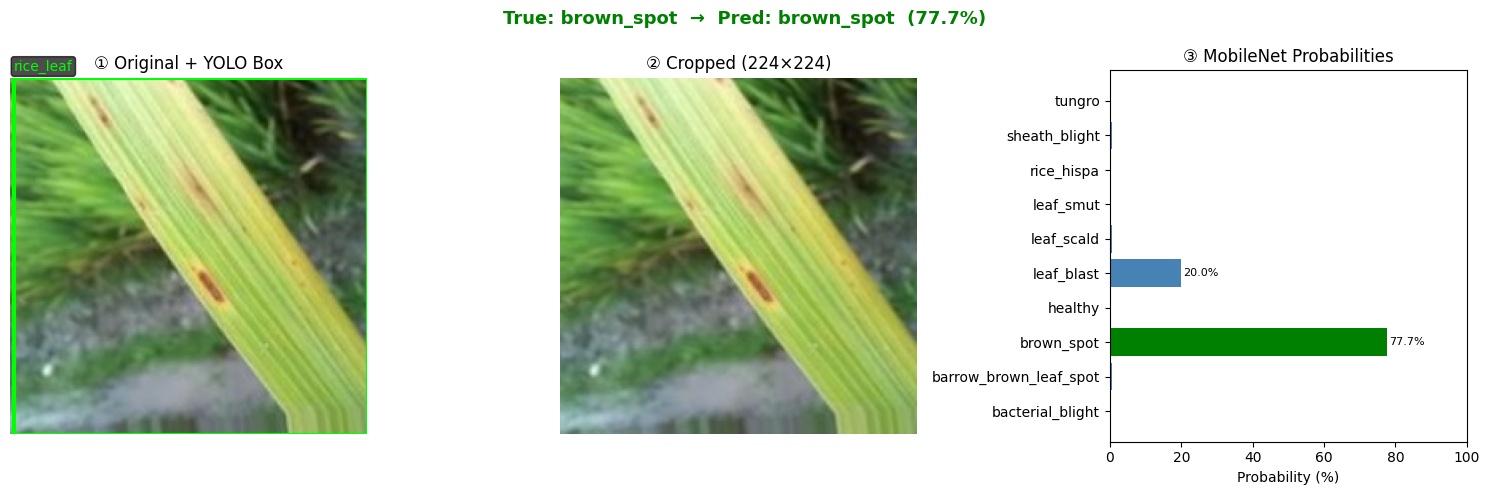

In [14]:
# ── 4. Visualize kết quả ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# [A] Ảnh gốc + bbox
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
axes[0].imshow(img_rgb)
if res['box_xyxy']:
    x1, y1, x2, y2 = res['box_xyxy']
    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                               linewidth=3, edgecolor='lime', facecolor='none')
    axes[0].add_patch(rect)
    axes[0].text(x1, y1-5, 'rice_leaf', color='lime', fontsize=10,
                 bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.7))
axes[0].set_title('① Original + YOLO Box', fontsize=12)
axes[0].axis('off')

# [B] Ảnh crop
crop_rgb = cv2.cvtColor(res['crop_bgr'], cv2.COLOR_BGR2RGB)
axes[1].imshow(crop_rgb)
axes[1].set_title('② Cropped (224×224)', fontsize=12)
axes[1].axis('off')

# [C] Probability bar chart
probs = res['all_probs']
colors = ['green' if cn == res['predicted_class'] else 'steelblue'
          for cn in CLASS_NAMES]
bars = axes[2].barh(CLASS_NAMES, probs * 100, color=colors)
axes[2].set_xlabel('Probability (%)')
axes[2].set_title('③ MobileNet Probabilities', fontsize=12)
axes[2].set_xlim(0, 100)
for bar, prob in zip(bars, probs):
    if prob > 0.02:
        axes[2].text(prob*100+0.5, bar.get_y()+bar.get_height()/2,
                     f'{prob*100:.1f}%', va='center', fontsize=8)

color = 'green' if res['predicted_class'] == true_label else 'red'
plt.suptitle(
    f"True: {true_label}  →  Pred: {res['predicted_class']}  ({res['confidence']*100:.1f}%)",
    fontsize=13, color=color, fontweight='bold'
)
plt.tight_layout()
plt.show()

In [15]:
# ── 5. Batch test 100 ảnh ngẫu nhiên ─────────────────────────────────
N_SAMPLES = 100
sample_paths = random.sample(all_test_imgs, min(N_SAMPLES, len(all_test_imgs)))

correct = 0
total   = 0
latencies_yolo = []
latencies_cls  = []
no_detect_count = 0

for img_path in sample_paths:
    true_cls = os.path.basename(os.path.dirname(img_path))
    if true_cls not in CLASS_NAMES:
        continue
    
    img = cv2.imread(img_path)
    if img is None:
        continue
    
    res = predict_pipeline(img, yolo, mobilenet,
                            conf=CONF_THRESHOLD, padding=PADDING)
    
    if res['predicted_class'] == true_cls:
        correct += 1
    if not res['yolo_detected']:
        no_detect_count += 1
    
    latencies_yolo.append(res['latency_yolo_ms'])
    latencies_cls.append(res['latency_cls_ms'])
    total += 1

accuracy = correct / total * 100

print("\n" + "="*55)
print(f"BATCH TEST RESULTS  ({total} images)")
print("="*55)
print(f"Accuracy          : {accuracy:.1f}%  ({correct}/{total})")
print(f"YOLO no-detect    : {no_detect_count} ({no_detect_count/total*100:.1f}%)")
print(f"YOLO latency      : avg {np.mean(latencies_yolo):.1f} ms")
print(f"Classifier latency: avg {np.mean(latencies_cls):.1f} ms")
total_avg = np.mean(latencies_yolo) + np.mean(latencies_cls)
print(f"Total avg latency : {total_avg:.1f} ms  (~{1000/total_avg:.0f} FPS)")


BATCH TEST RESULTS  (100 images)
Accuracy          : 84.0%  (84/100)
YOLO no-detect    : 10 (10.0%)
YOLO latency      : avg 63.0 ms
Classifier latency: avg 92.8 ms
Total avg latency : 155.8 ms  (~6 FPS)


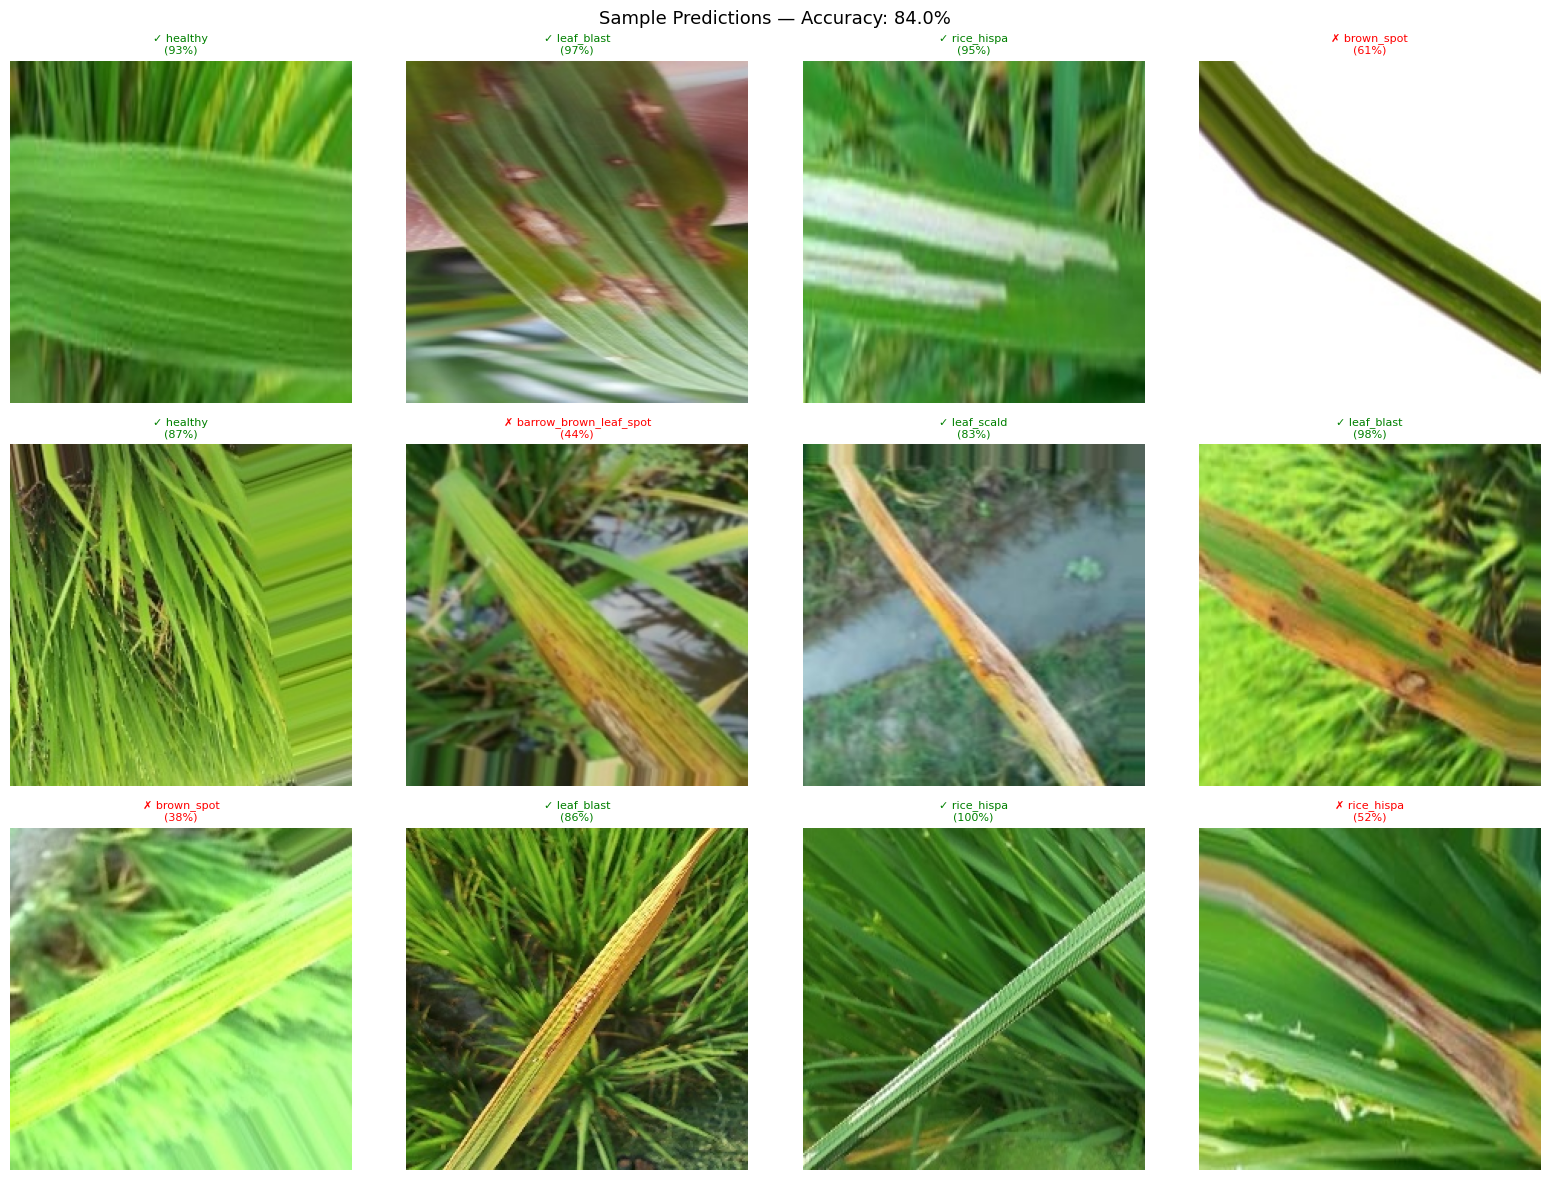

In [16]:
# ── 6. Visualize 12 ảnh sample từ batch test ──────────────────────────
sample_vis = random.sample(sample_paths[:total], min(12, total))

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for ax, img_path in zip(axes, sample_vis):
    true_cls = os.path.basename(os.path.dirname(img_path))
    img = cv2.imread(img_path)
    res = predict_pipeline(img, yolo, mobilenet,
                            conf=CONF_THRESHOLD, padding=PADDING)
    
    crop_rgb = cv2.cvtColor(res['crop_bgr'], cv2.COLOR_BGR2RGB)
    ax.imshow(crop_rgb)
    
    is_correct = res['predicted_class'] == true_cls
    color = 'green' if is_correct else 'red'
    mark  = '✓' if is_correct else '✗'
    ax.set_title(
        f"{mark} {res['predicted_class']}\n({res['confidence']*100:.0f}%)",
        fontsize=8, color=color
    )
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)
    ax.axis('off')

plt.suptitle(f'Sample Predictions — Accuracy: {accuracy:.1f}%', fontsize=13)
plt.tight_layout()
plt.show()

In [17]:
# ── 7. Summary ────────────────────────────────────────────────────────
print("="*60)
print("PIPELINE READY" if accuracy >= 70 else "⚠️  PIPELINE NEEDS IMPROVEMENT")
print("="*60)
print(f"  Pipeline accuracy : {accuracy:.1f}%")
print(f"  Avg total latency : {total_avg:.1f} ms")
print()
print("NEXT: Deploy Flask Server (see deploy_flask_server/)")
print("="*60)

PIPELINE READY
  Pipeline accuracy : 84.0%
  Avg total latency : 155.8 ms

NEXT: Deploy Flask Server (see deploy_flask_server/)
